# This in an attempt at GAN, Generative adversarial network using TENSORFLOW    

In [124]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import os
import glob
import random


In [125]:
def load_image_paths(base_folder):
    paths = []
    
    for date in os.listdir(base_folder):
        date_path = os.path.join(base_folder, date)
        if not os.path.isdir(date_path):
            continue
        
        paths += glob.glob(os.path.join(date_path, "*.webp"))
    
    return paths

IMG_SIZE = 64
base_folder = "../data/scrandle_padded_low_res_data"

image_paths = load_image_paths(base_folder)

random.shuffle(image_paths)
image_paths = image_paths[:2000]
print("Total images:", len(image_paths))


Total images: 2000


In [126]:
def preprocess(path):
    # ------------------------------
    # Load image
    # ------------------------------
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])

    # ------------------------------
    # Get dimensions
    # ------------------------------
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    # ------------------------------
    # REMOVE padding (Tensor-safe)
    # ------------------------------
    top = tf.cast(0.2 * tf.cast(h, tf.float32), tf.int32)
    right = tf.cast(0.8 * tf.cast(w, tf.float32), tf.int32)

    img = img[top:, :right, :]

    # ------------------------------
    # Resize
    # ------------------------------
    img = tf.image.resize(img, [64, 64])

    # ------------------------------
    # Normalize
    # ------------------------------
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1

    return img

In [127]:
def crop_black(img):
    gray = tf.reduce_mean(img, axis=-1)

    mask = gray > 10  # threshold
    coords = tf.where(mask)

    y_min = tf.reduce_min(coords[:,0])
    y_max = tf.reduce_max(coords[:,0])
    x_min = tf.reduce_min(coords[:,1])
    x_max = tf.reduce_max(coords[:,1])

    return img[y_min:y_max, x_min:x_max]

In [128]:
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
dataset = dataset.repeat()

In [133]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Input(shape=(100,)))

    model.add(layers.Dense(8 * 8 * 512, use_bias=False))  # ✅ larger
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Reshape((8, 8, 512)))  # ✅ FIXED

    model.add(layers.Conv2DTranspose(256, 4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(128, 4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh'))

    return model


In [134]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Input(shape=(64, 64, 3)))

    model.add(layers.Conv2D(64, 4, strides=2, padding='same'))   # 64 → 32
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 4, strides=2, padding='same'))  # 32 → 16
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, 4, strides=2, padding='same'))  # ✅ NEW → 16 → 8
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


In [135]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real, fake):
    return cross_entropy(tf.ones_like(real) * 0.9, real) + \
           cross_entropy(tf.zeros_like(fake), fake)

def g_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)



In [136]:
generator = build_generator()
discriminator = build_discriminator()

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)


In [137]:
@tf.function
def train_step(images):
    noise = tf.random.normal([images.shape[0], 100])

    with tf.GradientTape() as tape_g, tf.GradientTape() as tape_d:
        generated = generator(noise, training=True)

        real_out = discriminator(images, training=True)
        fake_out = discriminator(generated, training=True)

        loss_g = g_loss(fake_out)
        loss_d = d_loss(real_out, fake_out)

    grads_g = tape_g.gradient(loss_g, generator.trainable_variables)
    grads_d = tape_d.gradient(loss_d, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))


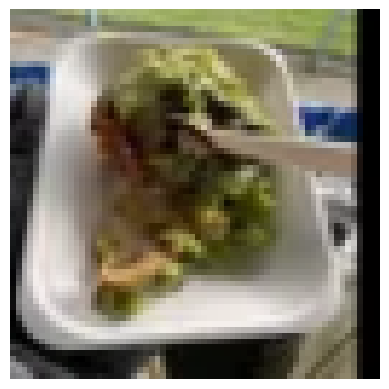

In [141]:
for x in dataset.take(1):
    img = (x[0] + 1) / 2
    plt.imshow(img)
    plt.axis("off")


In [142]:
steps_per_epoch = 200
EPOCHS = 40
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch}")

    for image_batch in dataset.take(steps_per_epoch):
        train_step(image_batch)
        




Epoch 0

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 11

Epoch 12

Epoch 13

Epoch 14

Epoch 15

Epoch 16

Epoch 17

Epoch 18

Epoch 19

Epoch 20

Epoch 21

Epoch 22

Epoch 23

Epoch 24

Epoch 25

Epoch 26

Epoch 27

Epoch 28

Epoch 29

Epoch 30

Epoch 31

Epoch 32

Epoch 33

Epoch 34

Epoch 35

Epoch 36

Epoch 37

Epoch 38

Epoch 39


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

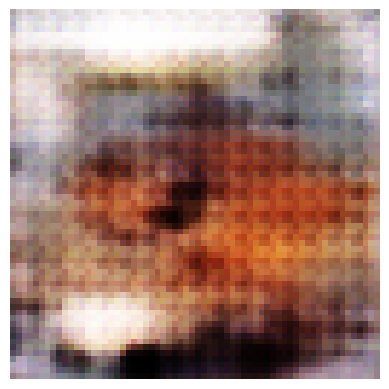

In [160]:
noise = tf.random.normal([1, 100])
generated = generator(noise, training=False)

img = (generated[0] + 1) / 2  # back to [0,1]

plt.imshow(img)
plt.axis("off")
